# Customer Segmentation with Actionable Business Insights

## Business Problem

An e-commerce company wants to segment customers based on purchasing behavior to improve marketing campaigns, customer retention, and product recommendations.

## Objectives

- Perform Exploratory Data Analysis
- Build Customer Segments using K-Means
- Predict Customer Spending
- Predict Purchase Likelihood
- Generate Business Insights


In [96]:
# ===============================
# Import Libraries
# ===============================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.metrics import (
    silhouette_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

plt.style.use("ggplot")

In [97]:
# ===============================
# Load Dataset
# ===============================

df = pd.read_excel("../data/online_retail_II.xlsx")

print("Shape:", df.shape)

df.head()

Shape: (525461, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [98]:
# ===============================
# Basic Dataset Information
# ===============================

print("Shape of Dataset:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Shape of Dataset: (525461, 8)

Columns:
Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

Data Types:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

Missing Values:
Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

Duplicate Rows:
6865


In [99]:
# Statistical Summary

df.describe(include='all')

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,525461.0,525461,522533,525461.000000,525461,525461.000000,417534.000000,525461
unique,28816.0,4632,4681,NaN,NaN,NaN,NaN,40
top,537434.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,675.0,3516,3549,NaN,NaN,NaN,NaN,485852
mean,NaN,NaN,NaN,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478,NaN
min,NaN,NaN,NaN,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2010-03-21 12:20:00,1.250000,13983.000000,NaN
50%,NaN,NaN,NaN,3.000000,2010-07-06 09:51:00,2.100000,15311.000000,NaN
75%,NaN,NaN,NaN,10.000000,2010-10-15 12:45:00,4.210000,16799.000000,NaN
max,NaN,NaN,NaN,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000,NaN


In [100]:
# First and Last Purchase Dates

print("Earliest Transaction:", df["InvoiceDate"].min())
print("Latest Transaction:", df["InvoiceDate"].max())

Earliest Transaction: 2009-12-01 07:45:00
Latest Transaction: 2010-12-09 20:01:00


In [101]:
# Number of Unique Customers

print("Unique Customers:", df["Customer ID"].nunique())

Unique Customers: 4383


In [102]:
# Number of Countries

print(df["Country"].value_counts())

Country
United Kingdom          485852
EIRE                      9670
Germany                   8129
France                    5772
Netherlands               2769
Spain                     1278
Switzerland               1187
Portugal                  1101
Belgium                   1054
Channel Islands            906
Sweden                     902
Italy                      731
Australia                  654
Cyprus                     554
Austria                    537
Greece                     517
United Arab Emirates       432
Denmark                    428
Norway                     369
Finland                    354
Unspecified                310
USA                        244
Japan                      224
Poland                     194
Malta                      172
Lithuania                  154
Singapore                  117
RSA                        111
Bahrain                    107
Canada                      77
Thailand                    76
Hong Kong                   76


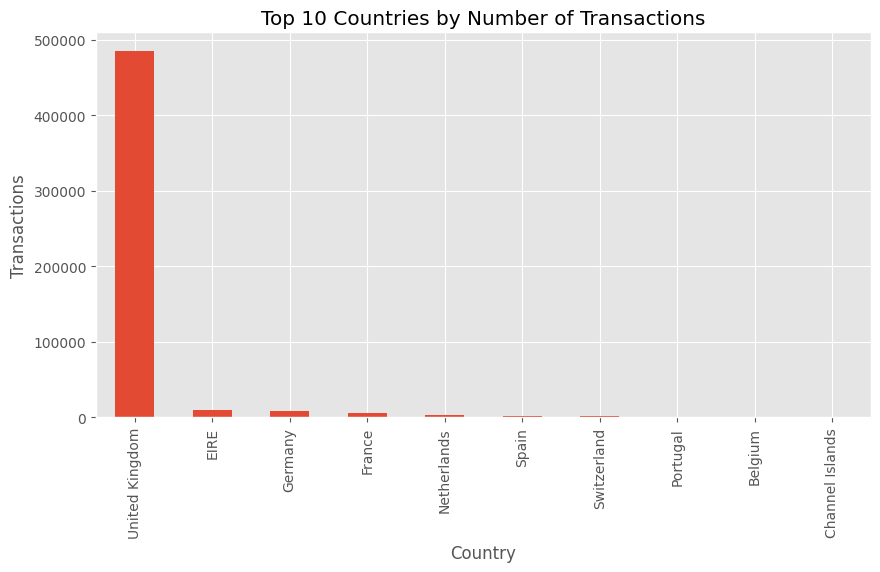

In [103]:
plt.figure(figsize=(10,5))

df["Country"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Countries by Number of Transactions")
plt.xlabel("Country")
plt.ylabel("Transactions")

plt.show()

In [104]:
# ======================================================
# Exploratory Data Analysis (EDA)
# ======================================================

print("="*60)
print("DATASET INFORMATION")
print("="*60)

print(f"Dataset Shape : {df.shape}")

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types")
display(df.dtypes)

print("\nMissing Values")
display(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nStatistical Summary")
display(df.describe())

print("\nUnique Customers:", df["Customer ID"].nunique())

print("\nUnique Countries:", df["Country"].nunique())

print("\nTop Countries")
display(df["Country"].value_counts().head(10))

DATASET INFORMATION
Dataset Shape : (525461, 8)

Columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

Data Types


Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object


Missing Values


Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64


Duplicate Rows: 6865

Statistical Summary


,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316



Unique Customers: 4383

Unique Countries: 40

Top Countries


Country
United Kingdom     485852
EIRE                 9670
Germany              8129
France               5772
Netherlands          2769
Spain                1278
Switzerland          1187
Portugal             1101
Belgium              1054
Channel Islands       906
Name: count, dtype: int64

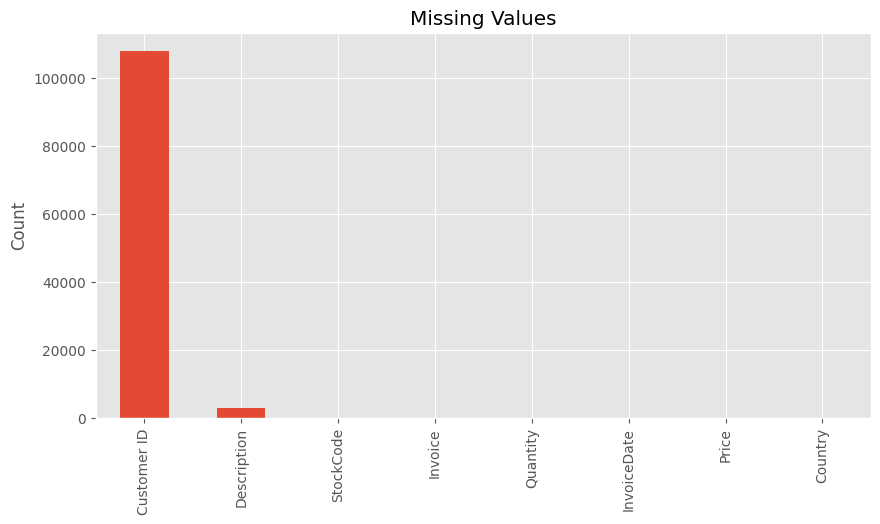

In [105]:
plt.figure(figsize=(10,5))

df.isnull().sum().sort_values(ascending=False).plot(kind="bar")

plt.title("Missing Values")
plt.ylabel("Count")

plt.show()

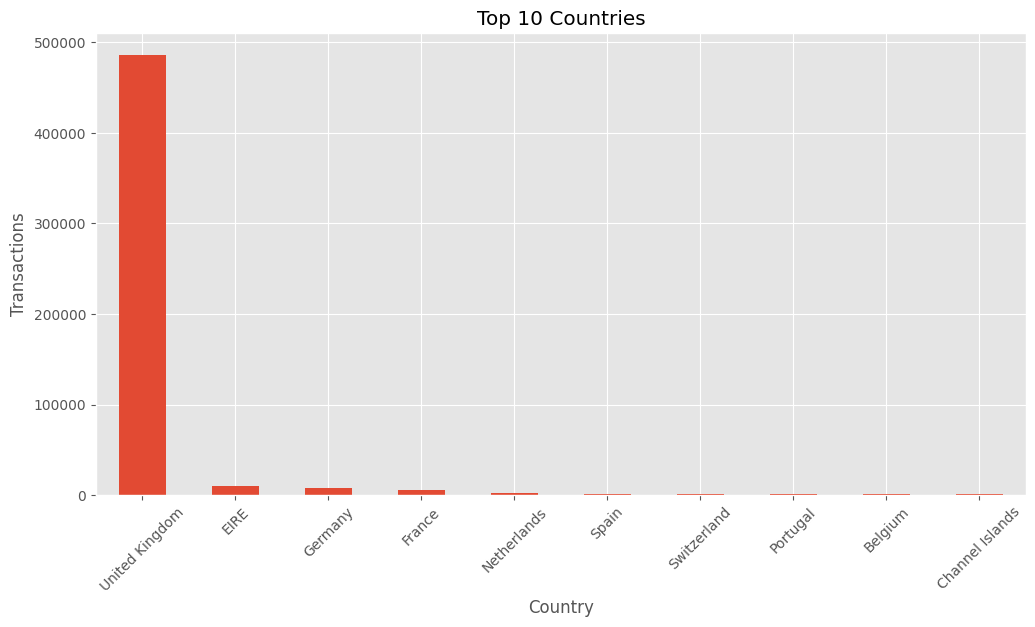

In [106]:
plt.figure(figsize=(12,6))

df["Country"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Countries")

plt.xlabel("Country")
plt.ylabel("Transactions")

plt.xticks(rotation=45)

plt.savefig("../reports/visualizations/top_10_countries.png", bbox_inches="tight")
plt.show()

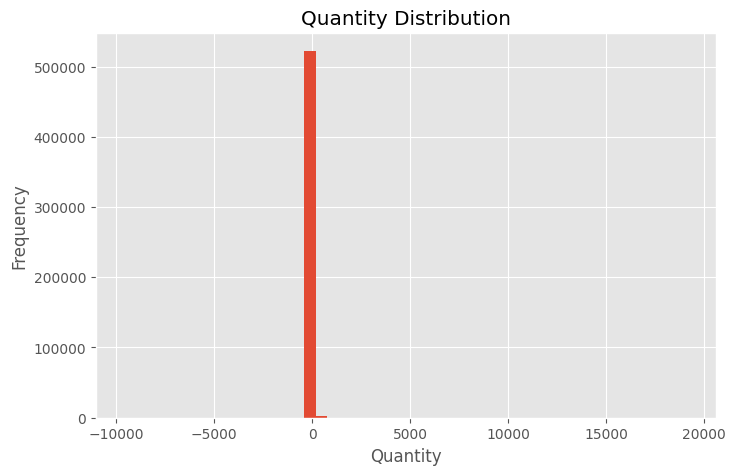

In [107]:
plt.figure(figsize=(8,5))

plt.hist(df["Quantity"], bins=50)

plt.title("Quantity Distribution")

plt.xlabel("Quantity")

plt.ylabel("Frequency")

plt.show()

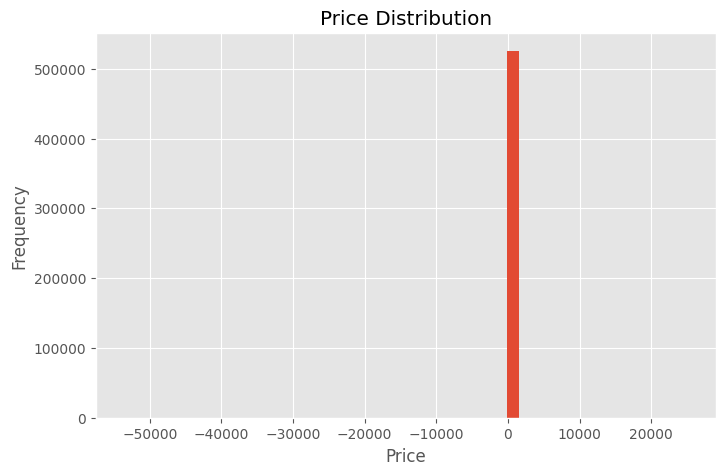

In [108]:
plt.figure(figsize=(8,5))

plt.hist(df["Price"], bins=50)

plt.title("Price Distribution")

plt.xlabel("Price")

plt.ylabel("Frequency")

plt.show()

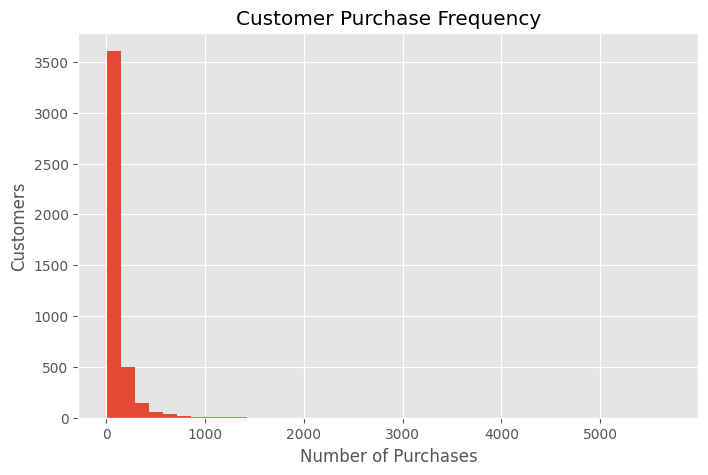

In [109]:
customer_orders = df.groupby("Customer ID")["Invoice"].count()

plt.figure(figsize=(8,5))

plt.hist(customer_orders, bins=40)

plt.title("Customer Purchase Frequency")

plt.xlabel("Number of Purchases")

plt.ylabel("Customers")

plt.show()

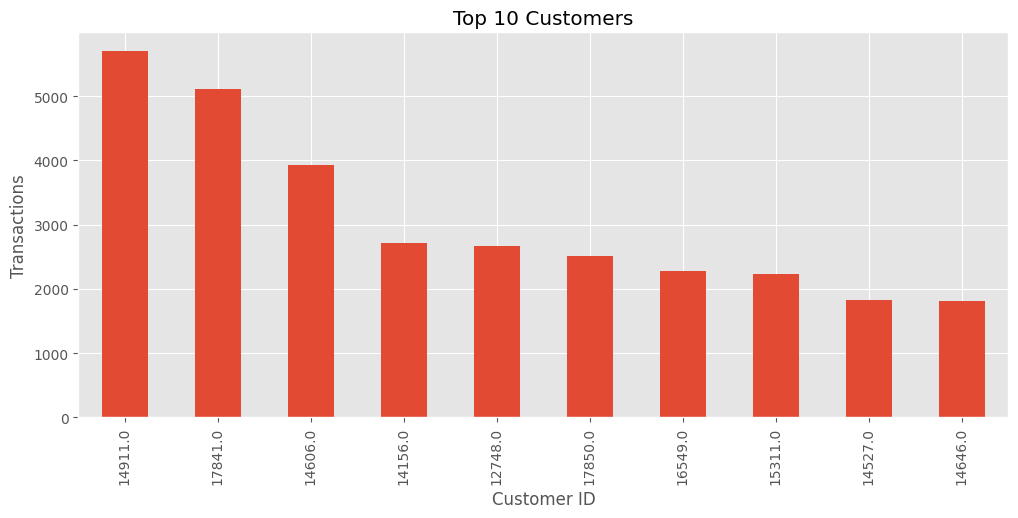

In [110]:
top_customers = customer_orders.sort_values(ascending=False).head(10)

plt.figure(figsize=(12,5))

top_customers.plot(kind="bar")

plt.title("Top 10 Customers")

plt.xlabel("Customer ID")

plt.ylabel("Transactions")

plt.show()

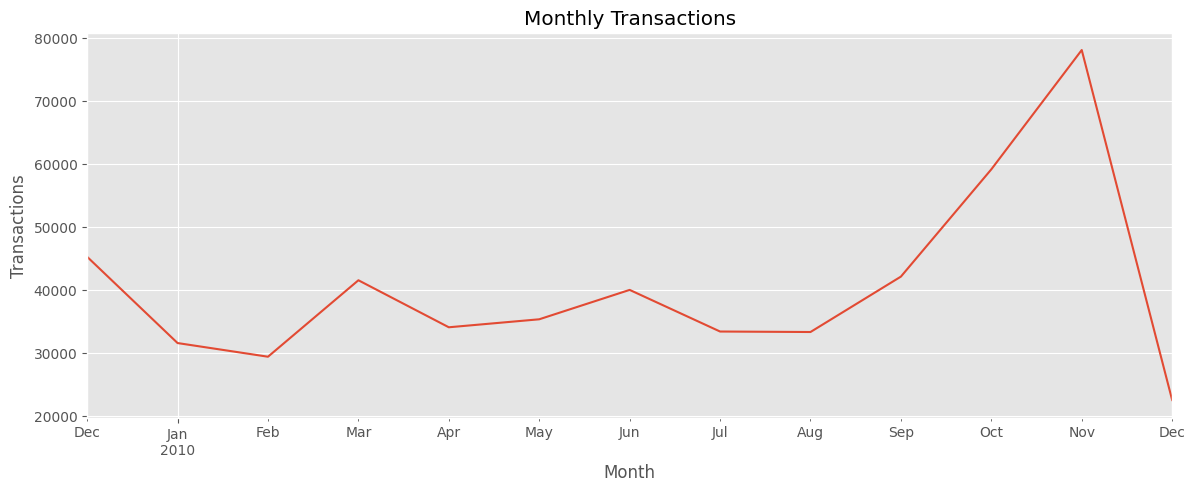

In [111]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

monthly_sales = df.groupby(df["InvoiceDate"].dt.to_period("M")).size()

plt.figure(figsize=(14,5))

monthly_sales.plot()

plt.title("Monthly Transactions")

plt.xlabel("Month")

plt.ylabel("Transactions")

plt.show()

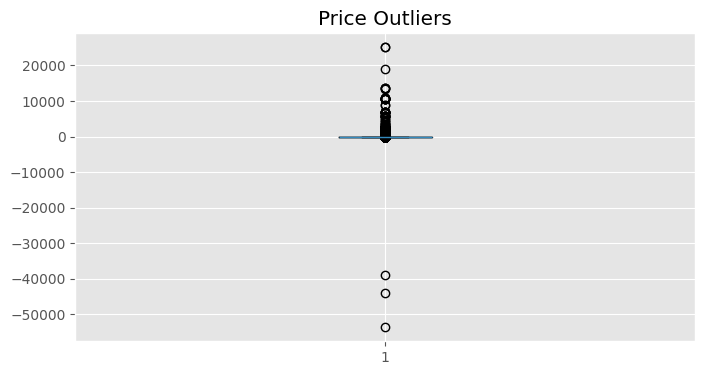

In [112]:
plt.figure(figsize=(8,4))

plt.boxplot(df["Price"])

plt.title("Price Outliers")

plt.show()

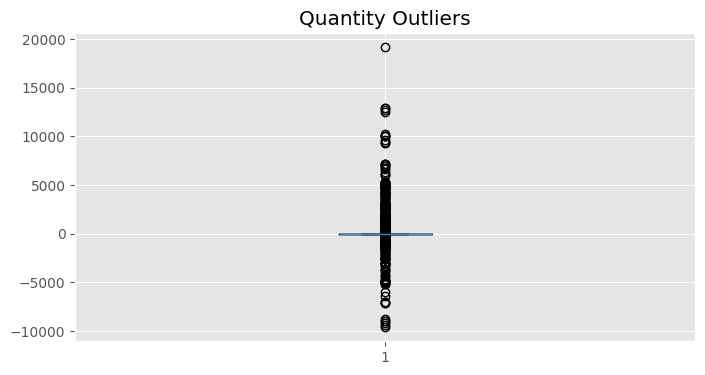

In [113]:
plt.figure(figsize=(8,4))

plt.boxplot(df["Quantity"])

plt.title("Quantity Outliers")

plt.show()

In [114]:
df["TotalAmount"] = df["Quantity"] * df["Price"]

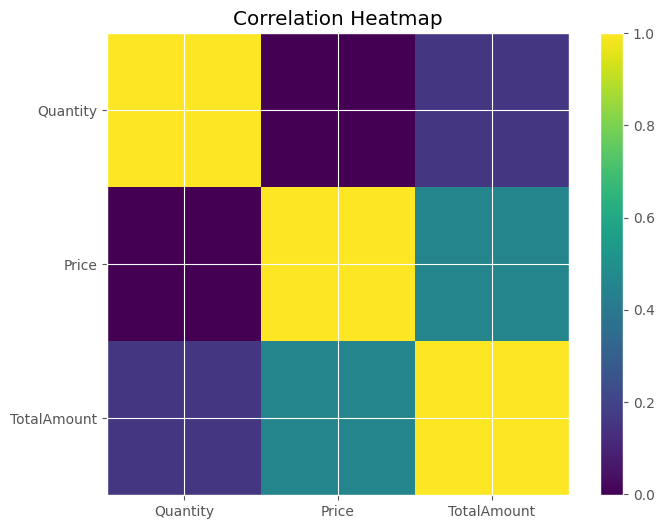

In [115]:
plt.figure(figsize=(8,6))

corr = df[["Quantity","Price","TotalAmount"]].corr()

plt.imshow(corr)

plt.xticks(range(len(corr.columns)), corr.columns)

plt.yticks(range(len(corr.columns)), corr.columns)

plt.colorbar()

plt.title("Correlation Heatmap")

plt.show()

In [116]:
# ==========================================================
# DATASET OVERVIEW
# ==========================================================

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

print("\nColumn Names")
print(df.columns.tolist())

print("\nData Types")
display(df.dtypes)

print("\nMissing Values")
display(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

DATASET OVERVIEW
Rows    : 525461
Columns : 9

Column Names
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'TotalAmount']

Data Types


Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
TotalAmount           float64
dtype: object


Missing Values


Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
TotalAmount         0
dtype: int64


Duplicate Rows
6865


In [117]:
# ==========================================================
# STATISTICAL SUMMARY
# ==========================================================

display(df.describe())

print("\nNumber of Unique Customers :", df["Customer ID"].nunique())
print("Number of Countries :", df["Country"].nunique())

,Quantity,InvoiceDate,Price,Customer ID,TotalAmount
count,525461.000000,525461,525461.000000,417534.000000,525461.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478,18.154506
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000,-53594.360000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000,3.750000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000,9.950000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000,17.700000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000,25111.090000
std,107.424110,NaN,146.126914,1680.811316,160.333083



Number of Unique Customers : 4383
Number of Countries : 40


In [118]:
# ==========================================================
# DATE RANGE
# ==========================================================

print("First Transaction :", df["InvoiceDate"].min())
print("Last Transaction  :", df["InvoiceDate"].max())

First Transaction : 2009-12-01 07:45:00
Last Transaction  : 2010-12-09 20:01:00


In [119]:
# ==========================================================
# DATA CLEANING
# ==========================================================

# Remove rows with missing Customer ID
df = df.dropna(subset=["Customer ID"])

# Remove cancelled invoices
df = df[~df["Invoice"].astype(str).str.startswith("C")]

# Remove negative quantities
df = df[df["Quantity"] > 0]

# Remove negative prices
df = df[df["Price"] > 0]

# Convert Customer ID to integer
df["Customer ID"] = df["Customer ID"].astype(int)

print("Dataset Shape After Cleaning:", df.shape)

Dataset Shape After Cleaning: (407664, 9)


In [120]:
# Create Total Amount Feature

df["TotalAmount"] = df["Quantity"] * df["Price"]

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


In [121]:
# Latest Transaction Date

snapshot_date = df["InvoiceDate"].max()

snapshot_date

Timestamp('2010-12-09 20:01:00')

In [122]:
# ==========================================================
# CREATE RFM DATASET
# ==========================================================

rfm = df.groupby("Customer ID").agg({

    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,

    "Invoice": "nunique",

    "TotalAmount": "sum"

})

rfm.columns = [

    "Recency",

    "Frequency",

    "Monetary"

]

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346,164,11,372.86
12347,2,2,1323.32
12348,73,1,222.16
12349,42,3,2671.14
12351,10,1,300.93


In [123]:
print(rfm.shape)

rfm.describe()

(4312, 3)


,Recency,Frequency,Monetary
count,4312.000000,4312.000000,4312.000000
mean,90.171846,4.455705,2048.238236
std,96.860633,8.170213,8914.481280
min,0.000000,1.000000,2.950000
25%,17.000000,1.000000,307.987500
50%,52.000000,2.000000,706.020000
75%,135.000000,5.000000,1723.142500
max,373.000000,205.000000,349164.350000


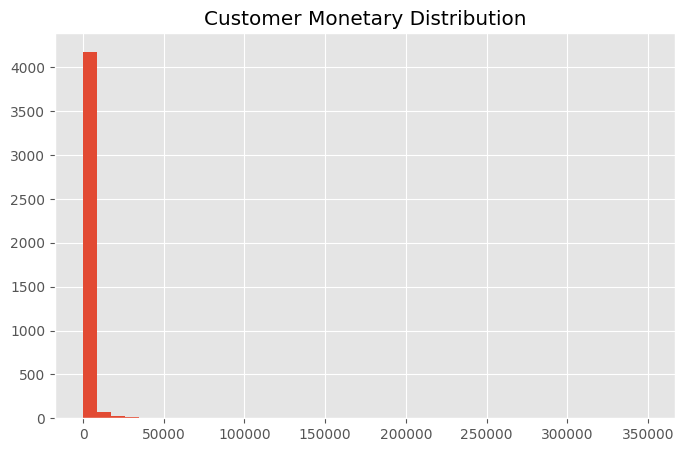

In [124]:
plt.figure(figsize=(8,5))

plt.hist(rfm["Monetary"], bins=40)

plt.title("Customer Monetary Distribution")

plt.show()

In [125]:
# ==========================================================
# FEATURE ENGINEERING
# ==========================================================

import numpy as np

# Simulated customer features (for project purposes)
np.random.seed(42)

rfm["WebsiteVisits"] = np.random.randint(5, 60, len(rfm))
rfm["DiscountUsage"] = np.random.randint(0, 10, len(rfm))
rfm["CustomerRating"] = np.round(np.random.uniform(2.5, 5.0, len(rfm)), 1)

rfm.head()

,Recency,Frequency,Monetary,WebsiteVisits,DiscountUsage,CustomerRating
Customer ID,,,,,,
12346,164,11,372.86,43,9,2.8
12347,2,2,1323.32,56,4,4.6
12348,73,1,222.16,33,1,2.8
12349,42,3,2671.14,19,8,3.8
12351,10,1,300.93,47,7,2.6


In [126]:
# Purchase Likelihood

rfm["PurchaseLikelihood"] = (
    (rfm["Frequency"] > rfm["Frequency"].median()) &
    (rfm["Monetary"] > rfm["Monetary"].median())
).astype(int)

rfm.head()

,Recency,Frequency,Monetary,WebsiteVisits,DiscountUsage,CustomerRating,PurchaseLikelihood
Customer ID,,,,,,,
12346,164,11,372.86,43,9,2.8,0
12347,2,2,1323.32,56,4,4.6,0
12348,73,1,222.16,33,1,2.8,0
12349,42,3,2671.14,19,8,3.8,1
12351,10,1,300.93,47,7,2.6,0


In [127]:
# Save customer-level dataset

rfm.to_csv("../data/customer_data.csv", index=True)

print("customer_data.csv saved successfully!")

customer_data.csv saved successfully!


In [128]:
# Features for Clustering

features = rfm[[
    "Recency",
    "Frequency",
    "Monetary",
    "WebsiteVisits",
    "DiscountUsage",
    "CustomerRating"
]]

In [129]:
# Standardize Features

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

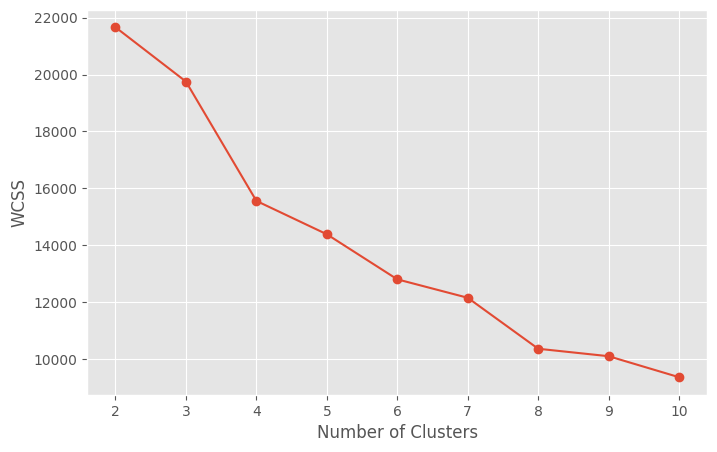

In [ ]:
# Elbow Method

wcss = []

for i in range(2,11):

    model = KMeans(n_clusters=i, random_state=42)

    model.fit(scaled_features)

    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(2,11), wcss, marker="o")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.savefig("../reports/visualizations/elbow_method.png", bbox_inches="tight")
plt.show()

In [131]:
# Train KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

rfm["Cluster"] = kmeans.fit_predict(scaled_features)

rfm.head()

,Recency,Frequency,Monetary,WebsiteVisits,DiscountUsage,CustomerRating,PurchaseLikelihood,Cluster
Customer ID,,,,,,,,
12346,164,11,372.86,43,9,2.8,0,0
12347,2,2,1323.32,56,4,4.6,0,0
12348,73,1,222.16,33,1,2.8,0,0
12349,42,3,2671.14,19,8,3.8,1,2
12351,10,1,300.93,47,7,2.6,0,0


In [132]:
# Silhouette Score

score = silhouette_score(
    scaled_features,
    rfm["Cluster"]
)

print("Silhouette Score :", score)

Silhouette Score : 0.1957610523675322


In [133]:
# Cluster Sizes

print(rfm["Cluster"].value_counts())

Cluster
2    1729
0    1658
1     912
3      13
Name: count, dtype: int64


In [134]:
# Cluster Profiles

cluster_summary = rfm.groupby("Cluster").mean()

cluster_summary

,Recency,Frequency,Monetary,WebsiteVisits,DiscountUsage,CustomerRating,PurchaseLikelihood
Cluster,,,,,,,
0,46.814837,4.926417,2130.527394,46.299759,4.588661,3.695115,0.503016
1,253.778509,1.586623,577.323656,32.586623,4.650219,3.751316,0.085526
2,46.104106,4.712551,1917.494865,18.512435,4.459803,3.824060,0.495084
3,3.230769,111.538462,112132.389231,40.538462,3.923077,3.761538,1.000000


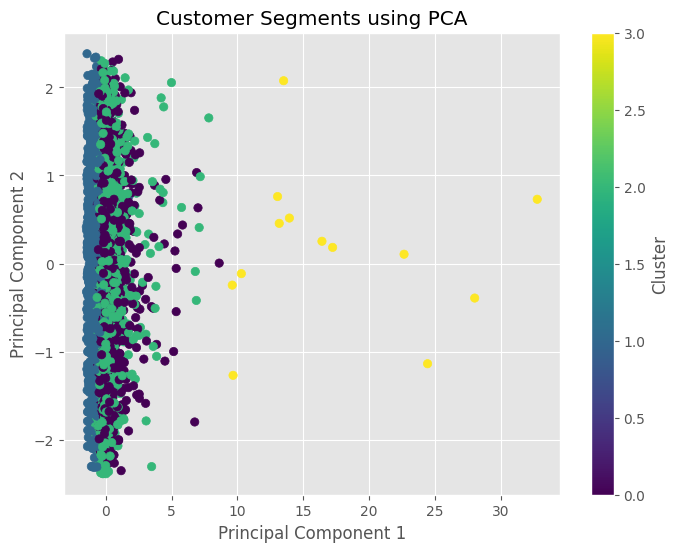

In [135]:
# ==========================================================
# PCA Visualization
# ==========================================================

pca = PCA(n_components=2)

pca_features = pca.fit_transform(scaled_features)

plt.figure(figsize=(8,6))

plt.scatter(
    pca_features[:,0],
    pca_features[:,1],
    c=rfm["Cluster"],
    cmap="viridis"
)

plt.title("Customer Segments using PCA")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")

plt.savefig("../reports/visualizations/customer_segments_pca.png", bbox_inches="tight")
plt.show()

In [136]:
# ==========================================================
# REGRESSION MODEL
# ==========================================================

X = rfm[[
    "Recency",
    "Frequency",
    "WebsiteVisits",
    "DiscountUsage",
    "CustomerRating"
]]

y = rfm["Monetary"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [137]:
model = LinearRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [138]:
print("MAE :", mean_absolute_error(y_test, predictions))

print("RMSE :", np.sqrt(mean_squared_error(y_test, predictions)))

print("R2 Score :", r2_score(y_test, predictions))

MAE : 1619.4386236758337
RMSE : 4772.284972241994
R2 Score : 0.1828020297932329


In [139]:
# ==========================================================
# CLASSIFICATION MODEL
# ==========================================================

X = rfm[[
    "Recency",
    "Frequency",
    "Monetary",
    "WebsiteVisits",
    "DiscountUsage",
    "CustomerRating"
]]

y = rfm["PurchaseLikelihood"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [140]:
classifier = LogisticRegression(max_iter=1000)

classifier.fit(X_train, y_train)

pred = classifier.predict(X_test)

In [141]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94       491
           1       0.94      0.90      0.92       372

    accuracy                           0.93       863
   macro avg       0.93      0.93      0.93       863
weighted avg       0.93      0.93      0.93       863



In [142]:
print("ROC-AUC Score")

print(roc_auc_score(
    y_test,
    classifier.predict_proba(X_test)[:,1]
))

ROC-AUC Score
0.9891323390929199
